## Question 1
- sistema la parte del Corporate Bond, a noi interessa solamente lo spread

In [2]:
# Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

### Data Description

| Category          | Variable | 
|--------------------|-----------|
| **Equity Index**   | S&P 500 | 
| **Government Yield** | US Treasury (10-year constant maturity) |
| **Corporate Yield** | ICE BofA US Corporate Index | 
| **Commodity**       | Natural Gas |
| **Forex Rate**      | GBP/USD |


In [3]:
# data import
equity_idx = pd.read_excel('../data/SPX Index.xlsx', header=5, usecols=[4, 5], index_col=0, names=['date', 'SPX'])
commodity = pd.read_excel('../data/GAS.xlsx', header=0, index_col=0, names=['date', 'Gas'])
fx_rate = pd.read_excel('../data/GBPUSD.xlsx', header=5, usecols=[4, 5], index_col=0, names=['date', 'GBPUSD'])
gvt_yield = pd.read_excel('../data/DGS10.xlsx', sheet_name='Daily', header=0, index_col=0, names=['date', '10yr Tr. Yield'])
corporate_yield = pd.read_excel('../data/BAMLC0A0CMEY.xlsx', sheet_name='Daily, Close', header=0, index_col=0, names=['date', 'US Yields'])
uk_gilt = pd.read_excel('../data/UKGilt.xlsx', header=0, index_col=0, names=['date', 'UKGilt'])


In [4]:
# Raw Levels aggregation 
df_level = pd.concat([equity_idx, gvt_yield, corporate_yield, commodity, fx_rate], join='inner', axis=1)
df_level = df_level.dropna(axis=0)
df_level['spread 10yr_Tr-Corp'] = df_level['US Yields'] - df_level['10yr Tr. Yield']

# Log-Levels
log_eq_idx = np.log(equity_idx)
log_commodity = np.log(commodity)
log_fx = np.log(fx_rate)
log_gvt = np.log(gvt_yield)
log_corp = np.log(corporate_yield)
log_spread = np.log(df_level['spread 10yr_Tr-Corp'])

# Log-Levels Dataframe
df_log = pd.concat([log_eq_idx, log_commodity, log_fx, log_gvt, log_corp, log_spread], join='inner', axis=1).dropna(axis=0)
df_log.columns = [f'log {equity_idx.columns[0]}',
                f'log {commodity.columns[0]}',
                f'log {fx_rate.columns[0]}',
                f'log {gvt_yield.columns[0]}',
                f'log {corporate_yield.columns[0]}',
                f'log {df_level.columns.to_list()[-1]}']

# Log-Differences Dataframe
df_log_diff = df_log.diff().dropna(axis=0)
df_log_diff.columns = [f'logDiff {equity_idx.columns[0]}',
                f'logDiff {commodity.columns[0]}',
                f'logDiff {fx_rate.columns[0]}',
                f'logDiff {gvt_yield.columns[0]}',
                f'logDiff {corporate_yield.columns[0]}',
                f'logDiff {df_level.columns.tolist()[-1]}']

# Comprehensive Dataframe
df = pd.concat([df_level, df_log, df_log_diff], join='inner', axis=1).dropna(axis=0)

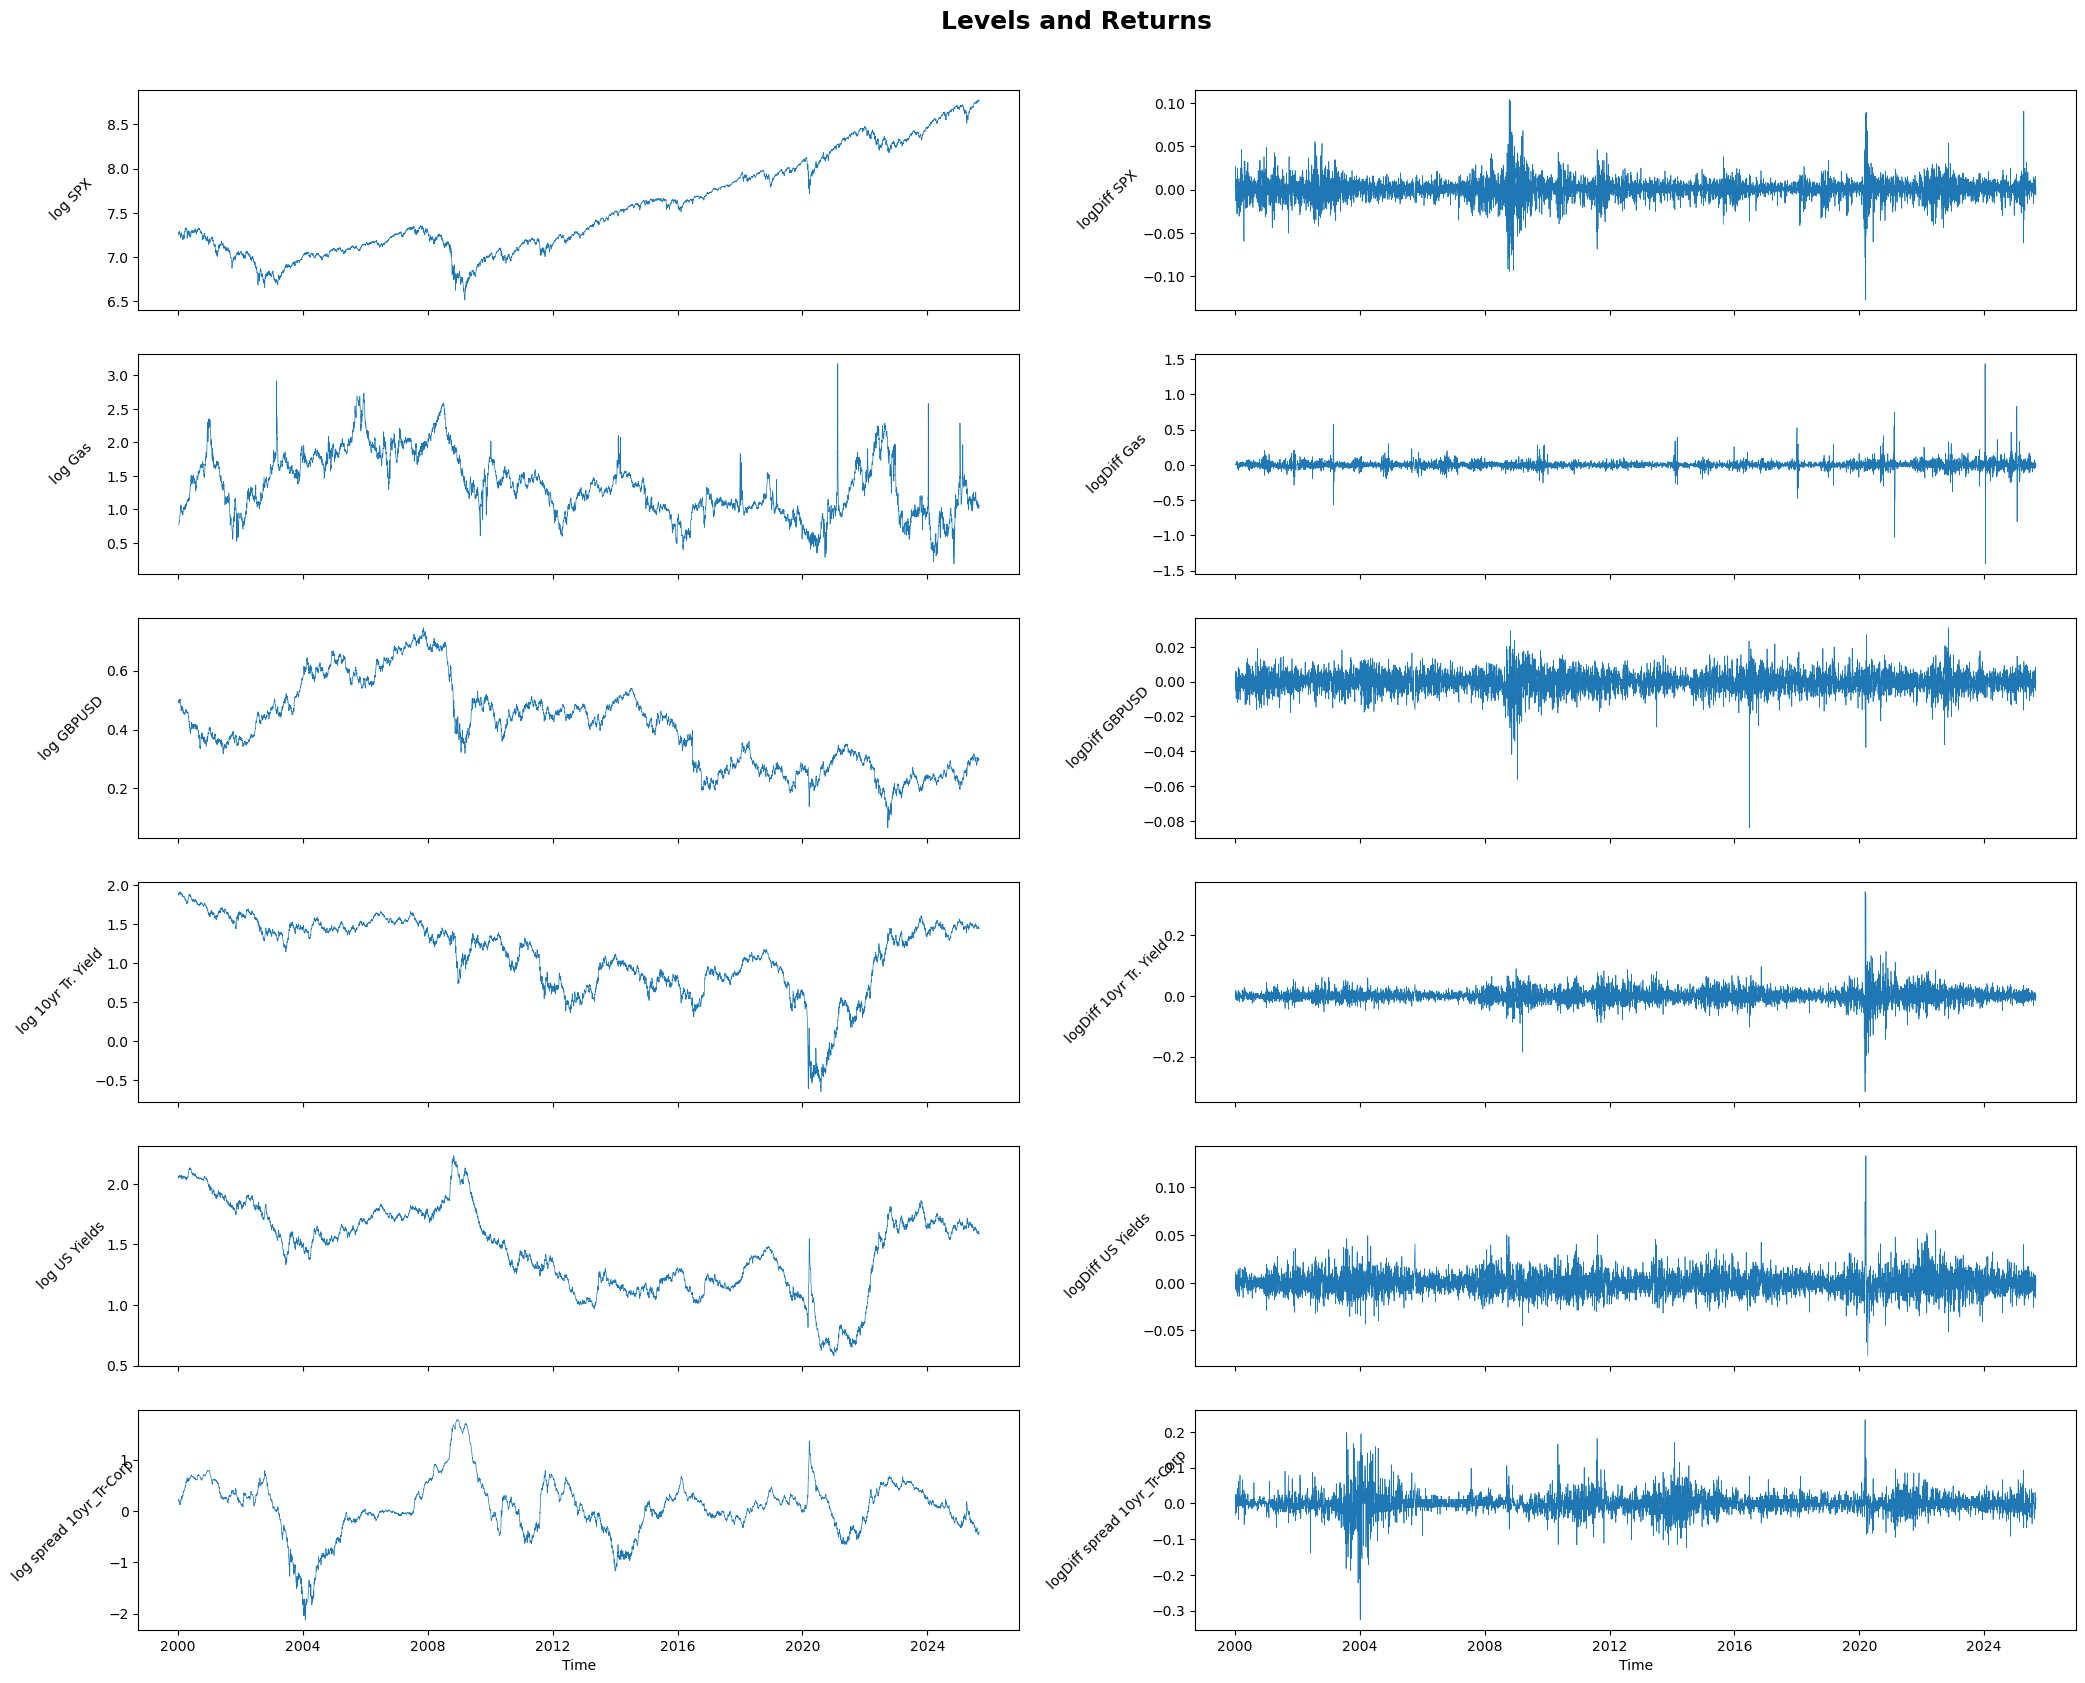

In [5]:
# Plot
names0 = df_log.columns.to_list()                                                       # Subplots names Col 0
names1 = df_log_diff.columns.to_list()                                                  # ' ' ' ' ' ' '  Col 1
nrows = 6                                               
ncols = 2
lw = .5
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(25, 20))                    # Plot Settings
plt.suptitle('Levels and Returns', y=0.92, fontsize=18, fontweight='bold')              # Plot Title
axs[-1, 0].set_xlabel('Time')                                                           # Plot common X-axis name
axs[-1, 1].set_xlabel('Time')                                                           # Plot common X-axis name

column = 0                                                                              # Index for plotting each column
for i in range(nrows):
    axs[i, 0].plot(df_log.index, df_log.iloc[:, column], linewidth=lw)                  # first-column subplot (Level)
    axs[i, 0].set_ylabel(f'{names0[column]}', rotation=45, labelpad=25, va='center')    # first subplot Y Label

    axs[i, 1].plot(df_log_diff.index, df_log_diff.iloc[:, column], linewidth=lw)        # second-column plot (Return)
    axs[i, 1].set_ylabel(f'{names1[column]}', rotation=45, labelpad=25, va='center')    # second subplot Y Label
    
    column += 1
plt.show()

In [6]:
# Table with the Descriptive Statistics
descriptive_stats = df_log_diff.describe().T
descriptive_stats['skew'] = df_log_diff.skew()
descriptive_stats['kurtosis'] = df_log_diff.kurt()
descriptive_stats = descriptive_stats.T
descriptive_stats

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
count,6372.000000,6372.000000,6372.000000,6372.000000,6372.000000,6372.000000
mean,0.000240,0.000045,-0.000030,-0.000067,-0.000072,-0.000099
std,0.012311,0.063056,0.005878,0.023679,0.011403,0.027269
min,-0.127652,-1.401562,-0.083955,-0.315081,-0.076508,-0.325422
25%,-0.004793,-0.022124,-0.003242,-0.011342,-0.006734,-0.011696
50%,0.000639,0.000000,0.000066,0.000000,0.000000,0.000000
75%,0.005973,0.020926,0.003353,0.011093,0.006252,0.010929
max,0.104236,1.432814,0.031033,0.341749,0.133189,0.233615
skew,-0.386924,0.103766,-0.839108,0.013070,0.762731,0.003333
kurtosis,10.493532,112.698715,10.122400,26.130671,7.438471,12.024244


In [7]:
# VarCov Matrix
varcov_matrix = df_log_diff.cov()
varcov_matrix

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
logDiff SPX,0.000152,0.000015,0.000015,0.000095,0.000016,-0.000085
logDiff Gas,0.000015,0.003976,0.000005,0.000008,-0.000011,-0.000015
logDiff GBPUSD,0.000015,0.000005,0.000035,-0.000004,-0.000010,-0.000011
logDiff 10yr Tr. Yield,0.000095,0.000008,-0.000004,0.000561,0.000199,-0.000297
logDiff US Yields,0.000016,-0.000011,-0.000010,0.000199,0.000130,-0.000033
logDiff spread 10yr_Tr-Corp,-0.000085,-0.000015,-0.000011,-0.000297,-0.000033,0.000744


In [8]:
# Correlation Matrix
corr_matrix = df_log_diff.corr()
corr_matrix

,logDiff SPX,logDiff Gas,logDiff GBPUSD,logDiff 10yr Tr. Yield,logDiff US Yields,logDiff spread 10yr_Tr-Corp
logDiff SPX,1.000000,0.018874,0.201290,0.324441,0.116690,-0.254556
logDiff Gas,0.018874,1.000000,0.012350,0.005123,-0.015113,-0.009002
logDiff GBPUSD,0.201290,0.012350,1.000000,-0.025416,-0.146281,-0.066890
logDiff 10yr Tr. Yield,0.324441,0.005123,-0.025416,1.000000,0.737805,-0.460173
logDiff US Yields,0.116690,-0.015113,-0.146281,0.737805,1.000000,-0.107559
logDiff spread 10yr_Tr-Corp,-0.254556,-0.009002,-0.066890,-0.460173,-0.107559,1.000000


In [9]:
from scipy.stats import norm

def pdf(df, name):
    #DataFrame to Series
    df = df.squeeze()
    
    # Moments of the Distribution
    mean = df.mean()
    st_dev = df.std()
    sk = df.skew()
    kurt = df.kurt()
    
    # Empirical Histogram
    plt.hist(df.to_numpy(), bins=100, density=True)

    # Theoretical PDF
    x = np.linspace(np.min(df), np.max(df), 100)
    pdf = norm.pdf(x, loc=mean, scale=st_dev)
    plt.plot(x, pdf)

    # Formatting a legend with main distribution specs
    text = (
        f"Mean = {mean:.2f}\n"
        f"Std.Dev. = {st_dev:.2f}\n"
        f"Skewness = {sk:.2f}\n"
        f"Kurtosis = {kurt:.2f}"
    )
    plt.legend(title=text, loc='upper right', fontsize=9, title_fontsize=10)
    
    # Labels and Title
    plt.xlabel(name)
    plt.ylabel('Density')
    plt.title(f'Empirical vs Normal PDF ({name})')
    
    plt.grid(alpha=0.3)
    plt.show()

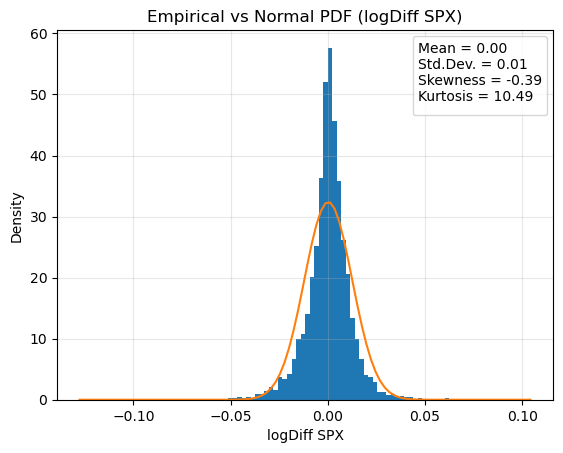

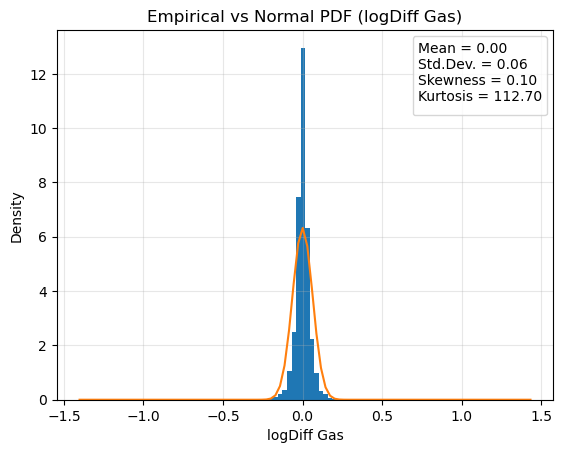

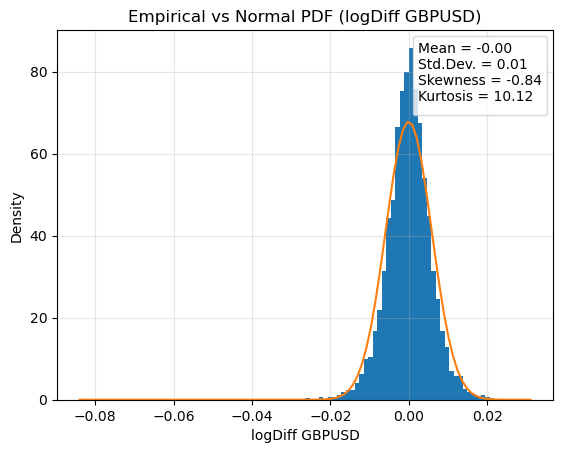

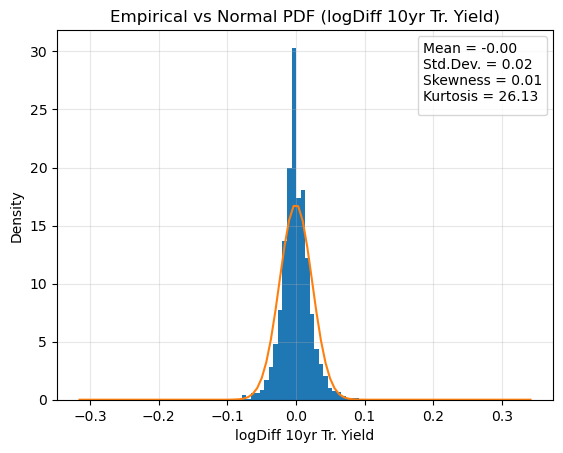

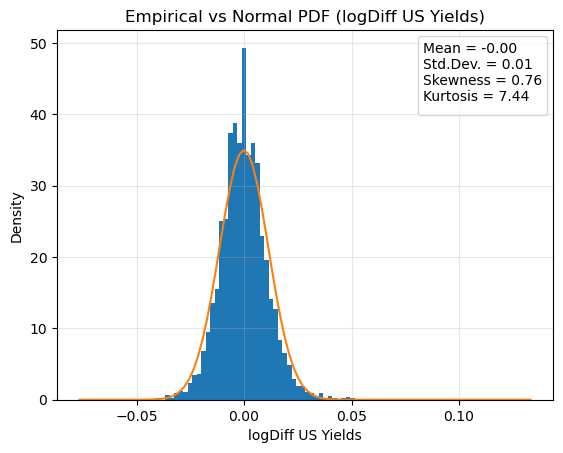

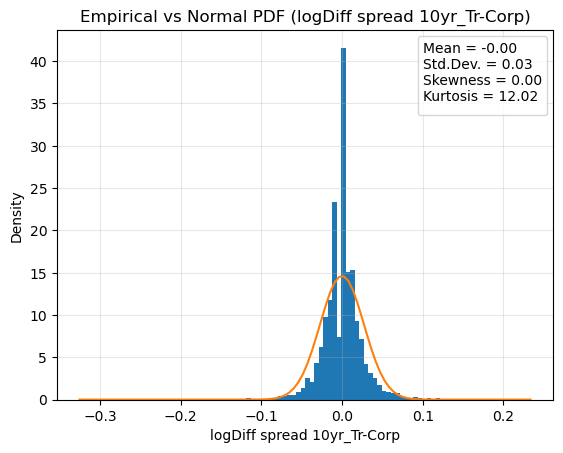

In [10]:
names = df_log_diff.columns.to_list()                                                  # ' ' ' ' ' ' '  Col 1
nrows = 6                                               

# Index for plotting each column

for i in range(nrows):
    pdf(df_log_diff.iloc[:, i], names[i])


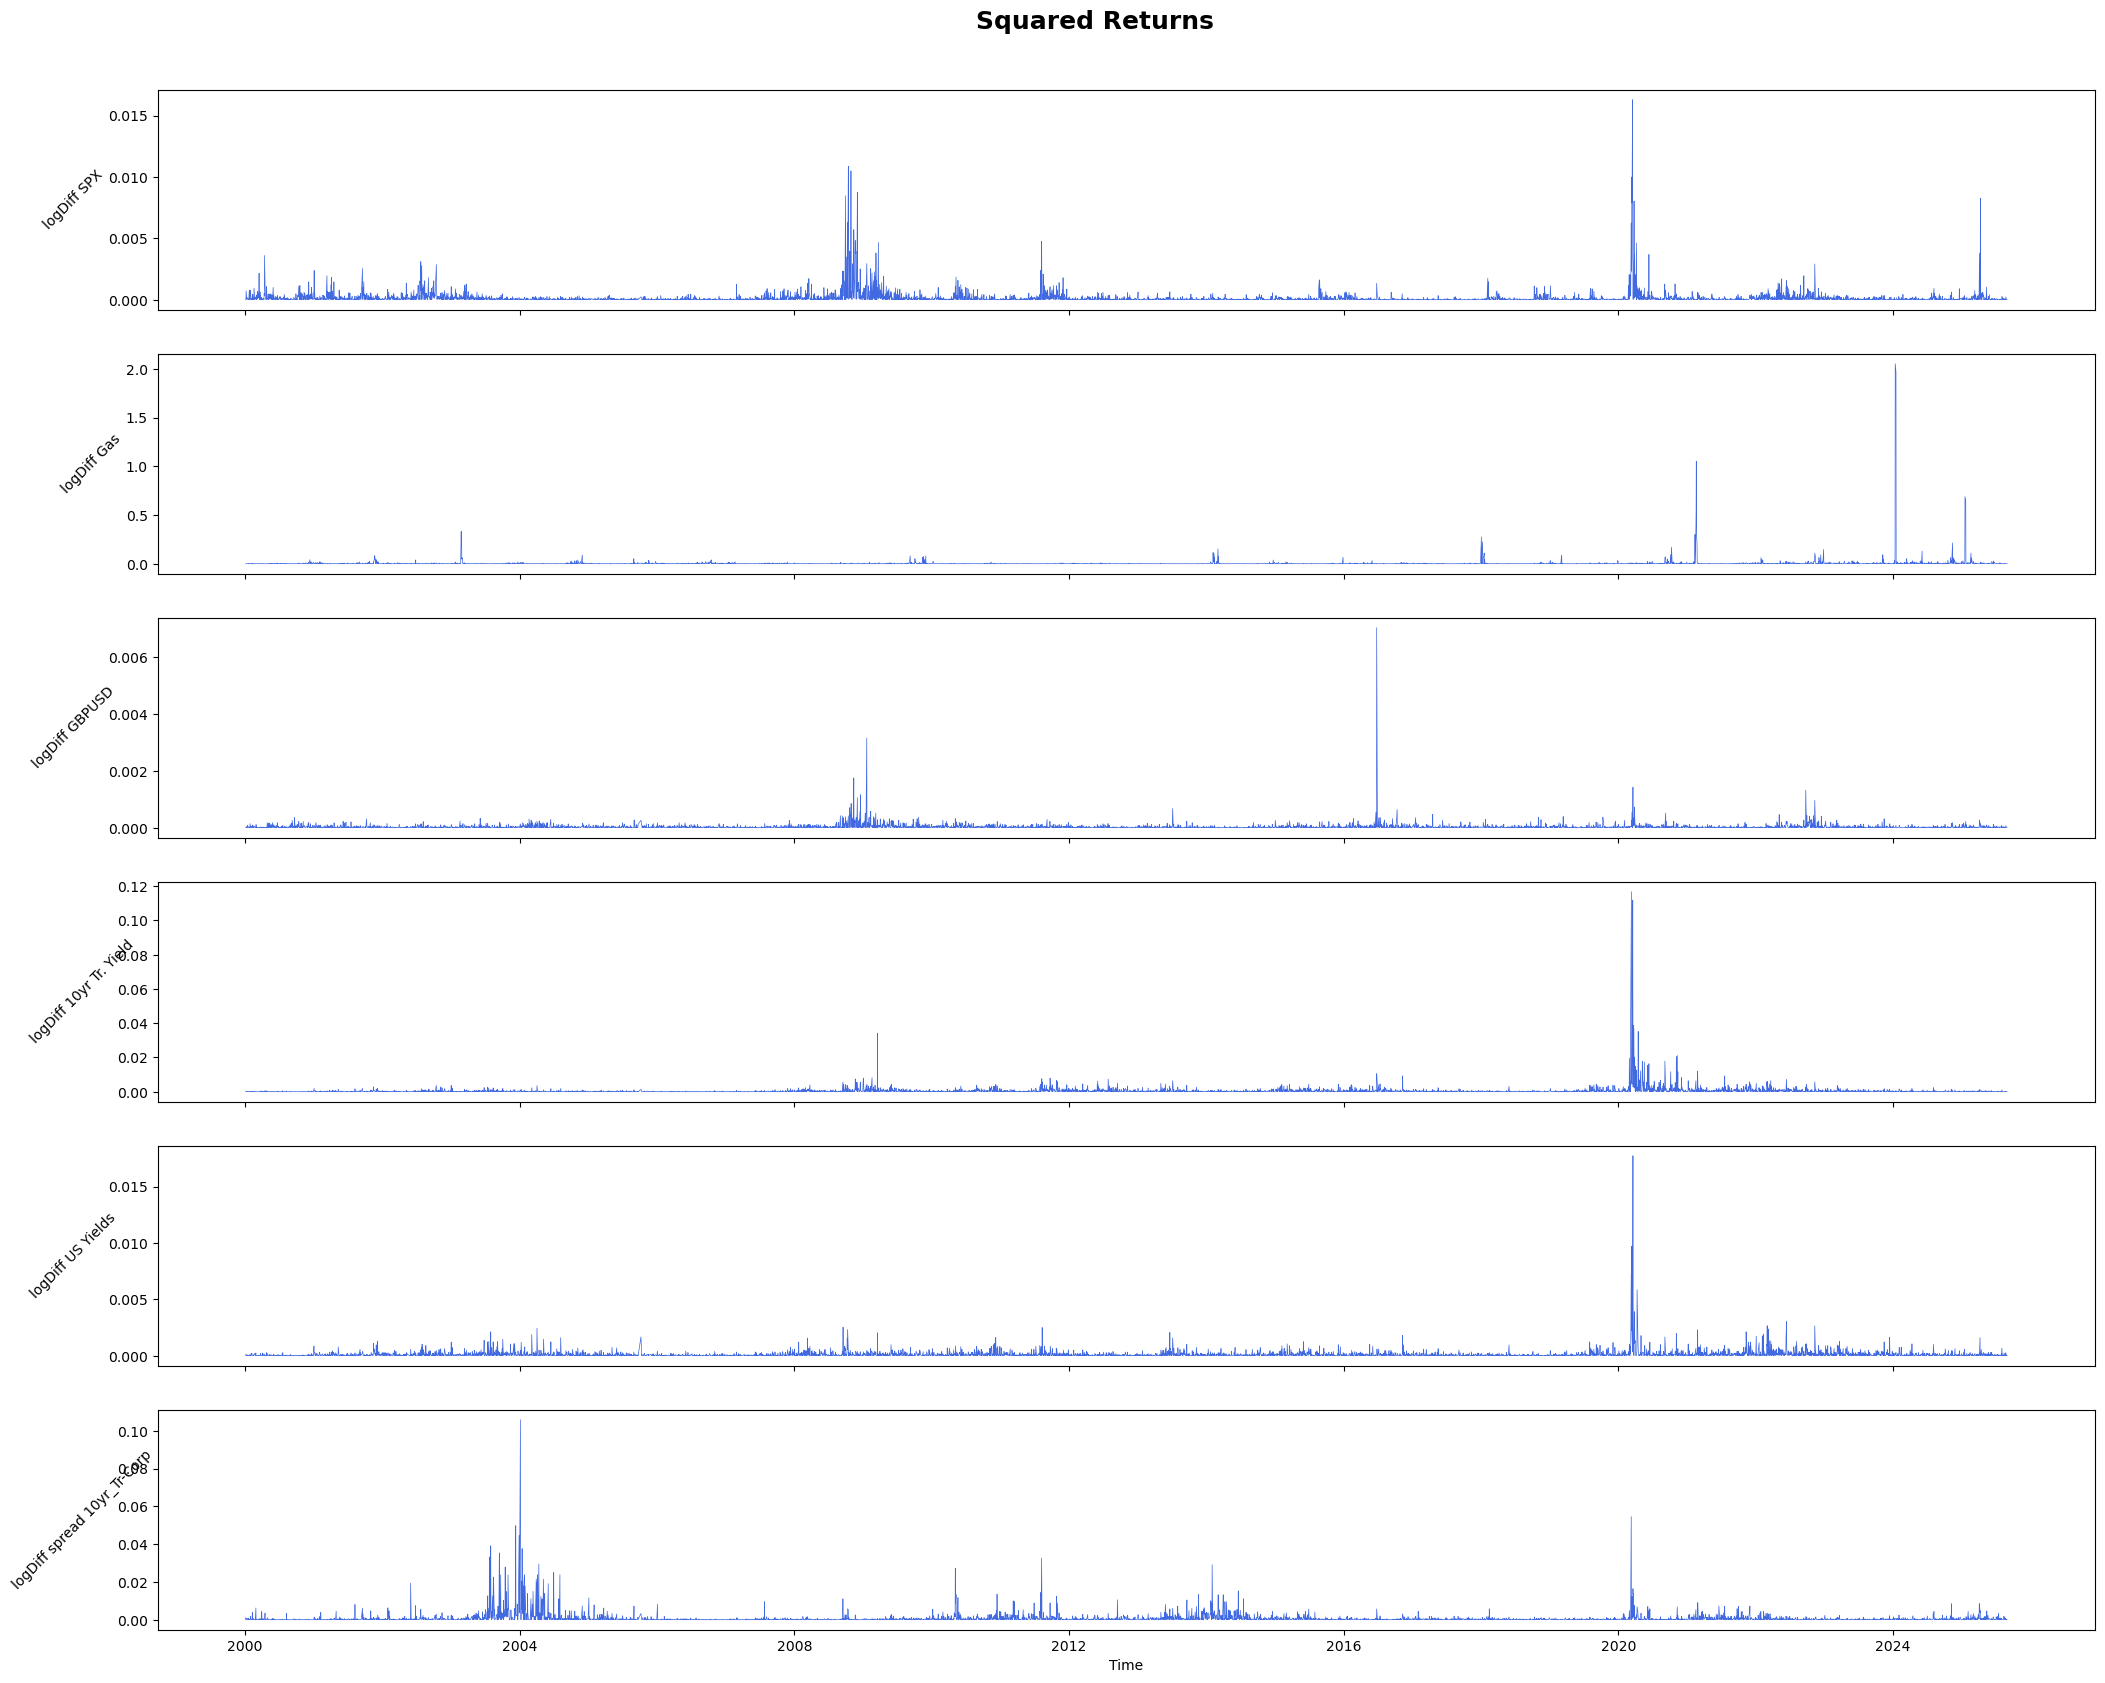

In [11]:
# Calculation of Squared Returns and Variance
df_sq_ret = df_log_diff ** 2                      
df_mean = df_log_diff.mean(axis=0)                
df_var = df_sq_ret - (df_mean ** 2)               

# Column Names
names_sq = df_sq_ret.columns.to_list()
names_var = df_var.columns.to_list()

# Plot Settings
nrows = 6
ncols = 1
lw = 0.5
fig, axs = plt.subplots(nrows, ncols, sharex=True, figsize=(25, 20))
plt.suptitle('Squared Returns', y=0.92, fontsize=18, fontweight='bold')

axs[-1].set_xlabel('Time')
# axs[-1, 1].set_xlabel('Time')

# Plot
column = 0
for i in range(nrows):
    # Left Column → squared returns
    axs[i].plot(df_sq_ret.index, df_sq_ret.iloc[:, column], linewidth=lw, color='royalblue')
    axs[i].set_ylabel(f'{names_sq[column]}', rotation=45, labelpad=25, va='center')

    # # Right Column → varianza centrata
    # axs[i, 1].plot(df_var.index, df_var.iloc[:, column], linewidth=lw, color='darkorange')
    # axs[i, 1].set_ylabel(f'{names_var[column]}', rotation=45, labelpad=25, va='center')

    column += 1

plt.show()

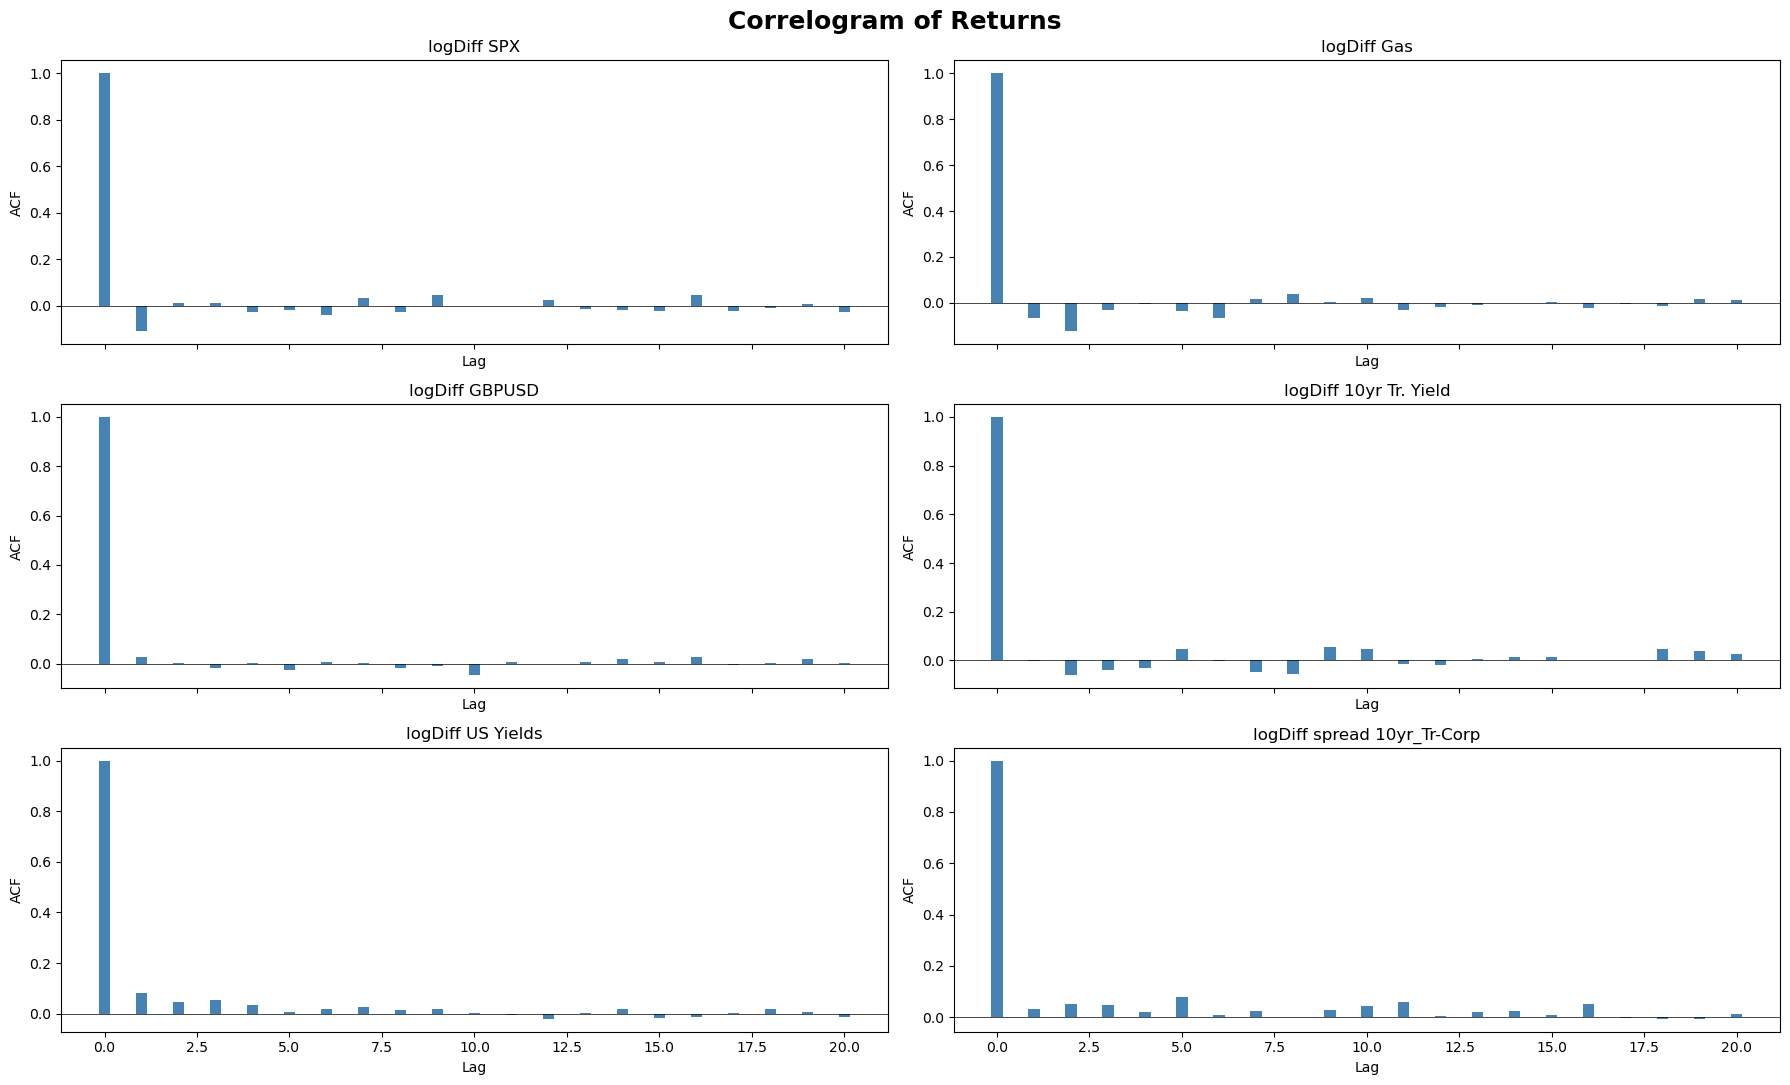

In [12]:
# Correlogram of Returns
max_lag = 20
names_ret = df_log_diff.columns.to_list()

nrows = 3
ncols = 2
fig, axs = plt.subplots(nrows, ncols, figsize=(18, 12), sharex=True)
plt.suptitle('Correlogram of Returns', y=0.93, fontsize=18, fontweight='bold')

def autocorr(x, max_lag):
    x = x - x.mean()
    denom = np.sum(x ** 2)
    acf_vals = [1.0]
    for k in range(1, max_lag + 1):
        num = np.sum(x[k:] * x[:-k])
        acf_vals.append(num / denom)
    return acf_vals

for idx, name in enumerate(names_ret):
    row, col = divmod(idx, ncols)
    series = df_log_diff[name].dropna().values
    acf_vals = autocorr(series, max_lag)
    lags = range(max_lag + 1)

    axs[row, col].bar(lags, acf_vals, width=0.3, color='steelblue')
    axs[row, col].axhline(0, color='black', linewidth=0.5)
    axs[row, col].set_title(name)
    axs[row, col].set_xlabel('Lag')
    axs[row, col].set_ylabel('ACF')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Question 2

In [13]:
# ADF Package
from statsmodels.tsa.stattools import adfuller

In [14]:
df_level_quarterly = df_level.resample('Q').last()
df_level_quarterly = df_level_quarterly.iloc[1:, :]

df_log_quarterly = df_log.resample('Q').last()
df_log_quarterly = df_log_quarterly.iloc[1:, :]

df_log_quarterly_diff = df_log_quarterly.diff().dropna(axis=0)


### Augmented Dickey-Fuller Test:
Now we are going to perfor the Unit Root Test for both the log-levels and, where applicable, the first difference of the time-series included in the perimeter.
Since we are using the package **adfuller** from **statsmodels**, the convention for the variables' names is different from Oxmetrics.
We will be considering the following equation:
$$\Delta{c_t}=\alpha+\beta t+\theta{c_{t-1}}+\delta_1{\Delta{c_{t-1}}}+u_t$$
Hence, when reporting the results we will use the following convention:
$$
x_1\rightarrow\theta\\
\text{const}\rightarrow\alpha\\
x_2\rightarrow\delta_1\\
x_3\rightarrow\delta_2\\
x_{-1}\rightarrow\beta$$
Where, by $x_{-1}$ we refer to the last coefficient reported in the summary test. (applicable only if we will specify the use of a **trend variable**)


In [15]:
def augm_Dickey_Fuller(data: pd.Series, lags: int, regression: str, first_diff=False):
    '''
    Computes an ADF test with manually chosen lag length and deterministic specification.
    Results are printed in a layout similar to OxMetrics.

    Parameters
    ----------
    data : pandas.Series
        The series on which the ADF test is performed (level or first difference).
    lags : int
        Number of lagged differences to include in the test regression.
    regression : str
        Type of deterministic component: "n" (none), "c" (constant), "ct" (constant + trend).
    first_diff : bool
        If True, marks the test title with a delta symbol to indicate first differencing.
    '''
    adf_results = adfuller(x=data, 
                        maxlag=lags, 
                        regression=regression, 
                        autolag=None, 
                        store=True,
                        regresults=True) # storing the results to facilitate the retrieving
    results_store = adf_results[-1]
    ols_res = results_store.resols

    # Parameters of the Test
    params = ols_res.params
    t_values = ols_res.tvalues
    p_values = ols_res.pvalues
    names = ols_res.model.exog_names
    crit_value_1 = adf_results[2]['1%']
    crit_value_5 = adf_results[2]['5%']
    
    # Title
    series_name = data.name if data.name is not None else "Series"
    if first_diff:
        title = f"ADF Test — Δ{series_name}"
    else:
        title = f"ADF Test — {series_name}"
    print("\n" + "="*60)
    print(title.center(60))
    print("="*60 + "\n")
    
    # Metrics
    print(f"{'Variable':<12}{'Coefficient':>12}{'t-Value':>12}{'P-Value':>12}")
    for i in range(len(names)):
        print("-" * 48)
        print(f"{names[i]:<12}{params[i]:>12.5f}{t_values[i]:>12.5f}{p_values[i]:>12.4f}")
    print(f'Critical values used in ADF test: 5%={crit_value_5:.3f}, 1%={crit_value_1:.3f}')

In [16]:
# Log SPX ADF: 4 lags, constant and trend
adf_logSPX = augm_Dickey_Fuller(df_log_quarterly['log SPX'], 4, 'ct')


                     ADF Test — log SPX                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.10821    -2.40009      0.0185
------------------------------------------------
x2               0.04263     0.41062      0.6823
------------------------------------------------
x3               0.03944     0.38894      0.6982
------------------------------------------------
x4              -0.05873    -0.57864      0.5643
------------------------------------------------
x5              -0.04594    -0.45150      0.6527
------------------------------------------------
const            0.71025     2.36510      0.0202
------------------------------------------------
x6               0.00253     2.91242      0.0045
Critical values used in ADF test: 5%=-3.457, 1%=-4.055


In [17]:
# Log SPX ADF: 0 lags, constant and trend
adf_logSPX = augm_Dickey_Fuller(df_log_quarterly['log SPX'], 0, 'ct')


                     ADF Test — log SPX                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.09814    -2.69177      0.0084
------------------------------------------------
const            0.63862     2.62686      0.0100
------------------------------------------------
x2               0.00227     3.29421      0.0014
Critical values used in ADF test: 5%=-3.455, 1%=-4.051


In [18]:
# DLog SPX ADF: 0 lags, constant and trend
adf_DlogSPX = augm_Dickey_Fuller(df_log_quarterly_diff['log SPX'], 0, 'ct', first_diff=True)


                    ADF Test — Δlog SPX                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.99892    -9.83816      0.0000
------------------------------------------------
const           -0.01379    -0.80931      0.4203
------------------------------------------------
x2               0.00057     1.91721      0.0582
Critical values used in ADF test: 5%=-3.455, 1%=-4.052


In [19]:
# DLog SPX ADF: 0 lags, constant
adf_DlogSPX = augm_Dickey_Fuller(df_log_quarterly_diff['log SPX'], 0, 'c')


                     ADF Test — log SPX                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.96091    -9.52045      0.0000
------------------------------------------------
const            0.01447     1.67020      0.0981
Critical values used in ADF test: 5%=-2.891, 1%=-3.498


In [20]:
# Log Treasury ADF: 4 lags, constant and trend
adf_log10yTr = augm_Dickey_Fuller(df_log_quarterly['log 10yr Tr. Yield'], 4, 'ct')


               ADF Test — log 10yr Tr. Yield                

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.11441    -1.88271      0.0630
------------------------------------------------
x2               0.06939     0.63225      0.5288
------------------------------------------------
x3              -0.02841    -0.25952      0.7958
------------------------------------------------
x4               0.03720     0.34386      0.7318
------------------------------------------------
x5              -0.03930    -0.36448      0.7164
------------------------------------------------
const            0.12979     1.28973      0.2004
------------------------------------------------
x6              -0.00023    -0.25004      0.8031
Critical values used in ADF test: 5%=-3.457, 1%=-4.055


In [21]:
# DLog Treasury ADF: 0 lags, constant
adf_log10yTr = augm_Dickey_Fuller(df_log_quarterly['log 10yr Tr. Yield'], 0, 'c')


               ADF Test — log 10yr Tr. Yield                

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.09988    -2.39416      0.0185
------------------------------------------------
const            0.10469     2.12876      0.0358
Critical values used in ADF test: 5%=-2.891, 1%=-3.497


In [22]:
# Log SPX ADF: 0 lags, constant
adf_Dlog10yTr = augm_Dickey_Fuller(df_log_quarterly_diff['log 10yr Tr. Yield'], 0, 'c', first_diff=True)


               ADF Test — Δlog 10yr Tr. Yield               

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.98983    -9.80083      0.0000
------------------------------------------------
const           -0.00312    -0.15489      0.8772
Critical values used in ADF test: 5%=-2.891, 1%=-3.498


In [23]:
# Log Corporate Spread ADF: 4 lags, constant and trend
adf_logCorpSpread = augm_Dickey_Fuller(df_log_quarterly['log spread 10yr_Tr-Corp'], 4, 'ct')


             ADF Test — log spread 10yr_Tr-Corp             

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.25980    -3.47918      0.0008
------------------------------------------------
x2               0.20002     1.94436      0.0550
------------------------------------------------
x3               0.13950     1.34638      0.1816
------------------------------------------------
x4               0.12511     1.19781      0.2341
------------------------------------------------
x5              -0.03369    -0.32078      0.7491
------------------------------------------------
const           -0.00243    -0.03732      0.9703
------------------------------------------------
x6               0.00033     0.28124      0.7792
Critical values used in ADF test: 5%=-3.457, 1%=-4.055


In [24]:
# Log Corporate Spread ADF: 0 lags, constant
adf_logCorpSpread = augm_Dickey_Fuller(df_log_quarterly['log spread 10yr_Tr-Corp'], 0, 'c')


             ADF Test — log spread 10yr_Tr-Corp             

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.17400    -3.08858      0.0026
------------------------------------------------
const            0.00458     0.14377      0.8860
Critical values used in ADF test: 5%=-2.891, 1%=-3.497


In [25]:
# DLog Corporate Spread ADF: 4 lags, constant
adf_DlogCorpSpread = augm_Dickey_Fuller(df_log_quarterly_diff['log spread 10yr_Tr-Corp'], 0, 'c', first_diff=True)


            ADF Test — Δlog spread 10yr_Tr-Corp             

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.91136    -9.04991      0.0000
------------------------------------------------
const           -0.00934    -0.28183      0.7787
Critical values used in ADF test: 5%=-2.891, 1%=-3.498


In [26]:
# Log Natural Gas ADF: 4 lags, constant and trend
adf_logNatGas = augm_Dickey_Fuller(df_log_quarterly['log Gas'], 4, 'ct')


                     ADF Test — log Gas                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.28634    -3.41024      0.0010
------------------------------------------------
x2               0.12201     1.11811      0.2665
------------------------------------------------
x3               0.17099     1.69487      0.0936
------------------------------------------------
x4              -0.10907    -1.13057      0.2612
------------------------------------------------
x5               0.03391     0.35299      0.7249
------------------------------------------------
const            0.51715     3.32557      0.0013
------------------------------------------------
x6              -0.00272    -2.41182      0.0179
Critical values used in ADF test: 5%=-3.457, 1%=-4.055


In [27]:
# Log Natural Gas ADF: 0 lags, constant and trend
adf_logNatGas = augm_Dickey_Fuller(df_log_quarterly['log Gas'], 0, 'ct')


                     ADF Test — log Gas                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.26240    -3.86573      0.0002
------------------------------------------------
const            0.46264     3.53931      0.0006
------------------------------------------------
x2              -0.00220    -2.08388      0.0398
Critical values used in ADF test: 5%=-3.455, 1%=-4.051


In [28]:
# DLog Natural Gas ADF: 0 lags, constant and trend
adf_DlogNatGas = augm_Dickey_Fuller(df_log_quarterly_diff['log Gas'], 0, 'ct', first_diff=True)


                    ADF Test — Δlog Gas                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -1.01607   -10.01574      0.0000
------------------------------------------------
const           -0.00550    -0.09560      0.9240
------------------------------------------------
x2              -0.00001    -0.00525      0.9958
Critical values used in ADF test: 5%=-3.455, 1%=-4.052


In [29]:
# DLog Natural Gas ADF: 0 lags, constant and trend
adf_DlogNatGas = augm_Dickey_Fuller(df_log_quarterly_diff['log Gas'], 0, 'c', first_diff=True)


                    ADF Test — Δlog Gas                     

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -1.01607   -10.06726      0.0000
------------------------------------------------
const           -0.00576    -0.20286      0.8397
Critical values used in ADF test: 5%=-2.891, 1%=-3.498


In [30]:
# Log GBP/USD ADF: 4 lags, constant and trend
adf_logGBPUSD = augm_Dickey_Fuller(df_log_quarterly['log GBPUSD'], 4, 'ct')


                   ADF Test — log GBPUSD                    

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.16228    -3.08945      0.0027
------------------------------------------------
x2               0.14737     1.44070      0.1531
------------------------------------------------
x3              -0.08984    -0.86785      0.3878
------------------------------------------------
x4               0.03557     0.34769      0.7289
------------------------------------------------
x5               0.01603     0.15545      0.8768
------------------------------------------------
const            0.10297     3.12350      0.0024
------------------------------------------------
x6              -0.00076    -2.86980      0.0051
Critical values used in ADF test: 5%=-3.457, 1%=-4.055


In [31]:
# Log GBP/USD ADF: 0 lags, constant and trend
adf_logGBPUSD = augm_Dickey_Fuller(df_log_quarterly['log GBPUSD'], 0, 'ct')


                   ADF Test — log GBPUSD                    

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.11488    -2.58939      0.0111
------------------------------------------------
const            0.06959     2.51342      0.0136
------------------------------------------------
x2              -0.00047    -2.11188      0.0372
Critical values used in ADF test: 5%=-3.455, 1%=-4.051


In [32]:
# Log GBP/USD ADF: 0 lags, constant and trend
adf_DlogGBPUSD = augm_Dickey_Fuller(df_log_quarterly_diff['log GBPUSD'], 0, 'ct', first_diff=True)


                   ADF Test — Δlog GBPUSD                   

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.92961    -9.19196      0.0000
------------------------------------------------
const            0.00284     0.29992      0.7649
------------------------------------------------
x2              -0.00007    -0.44457      0.6576
Critical values used in ADF test: 5%=-3.455, 1%=-4.052


In [33]:
# Log GBP/USD ADF: 0 lags, constant
adf_DlogGBPUSD = augm_Dickey_Fuller(df_log_quarterly_diff['log GBPUSD'], 0, 'c', first_diff=True)


                   ADF Test — Δlog GBPUSD                   

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.92817    -9.22025      0.0000
------------------------------------------------
const           -0.00082    -0.17407      0.8622
Critical values used in ADF test: 5%=-2.891, 1%=-3.498


## Question 3

In [34]:
# OLS Package
import statsmodels.api as sm

In [35]:
def linear_regression(y, x, intercept=True, coefficients=False):
    '''
        The following function is appointed for the calculation of a Linear Regression for Cointegration
            analysis purposes.
        Hence, it will return the residuals of  the regression, ready to perform an ADF test on.
        y: Dependent Variable
        x: Independent Variable
        intercept: if True alpha != 0 else 0
    '''
    if intercept:
        x = sm.add_constant(x)
    
    model = sm.OLS(y, x, missing='drop')
    results = model.fit()
    
    alpha = results.params[0]
    beta = results.params[1]
    print('='*48)
    print(f"{'Parameters':<12}{'Alpha':>12}{'Beta':>12}")
    print('-'*48)
    print(f"{'Values':<12}{alpha:>12.3f}{beta:>12.3f}")
    print('='*48)
    residuals = results.resid

    return residuals


In [36]:
# Pair 1: SPX | 10-years Treasury Yield
# Linear Regression
resid_spx_treasury = linear_regression(df_log_quarterly['log SPX'], df_log_quarterly['log 10yr Tr. Yield'])

# ADF Test: Residuals of the LR
adf_cointeg_spx_treasury = augm_Dickey_Fuller(resid_spx_treasury, 4, 'n')

# ADF Test: Residuals of the LR without Lags
adf_cointeg_spx_treasury = augm_Dickey_Fuller(resid_spx_treasury, 0, 'n')

Parameters         Alpha        Beta
------------------------------------------------
Values             7.928      -0.349

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1               0.01066     0.36833      0.7135
------------------------------------------------
x2              -0.01925    -0.17809      0.8590
------------------------------------------------
x3              -0.04102    -0.38282      0.7027
------------------------------------------------
x4              -0.01587    -0.14836      0.8824
------------------------------------------------
x5              -0.07943    -0.74409      0.4587
Critical values used in ADF test: 5%=-1.944, 1%=-2.589

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1               0.00211     0.08507      0.9324
Critical v

In [37]:
# Pair 2: SPX | Corporate Spread
# Linear Regression
resid_spx_corpSpread = linear_regression(df_log_quarterly['log SPX'], df_log_quarterly['log spread 10yr_Tr-Corp'])

# ADF Test: Residuals of the LR
adf_cointeg_spx_corpSpread = augm_Dickey_Fuller(resid_spx_corpSpread, 4, 'n')

# ADF Test: Residuals of the LR without Lags
adf_cointeg_spx_corpSpread = augm_Dickey_Fuller(resid_spx_corpSpread, 0, 'n')


Parameters         Alpha        Beta
------------------------------------------------
Values             7.554      -0.075

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1               0.00638     0.44216      0.6594
------------------------------------------------
x2               0.08807     0.83455      0.4061
------------------------------------------------
x3               0.06123     0.58742      0.5584
------------------------------------------------
x4              -0.00972    -0.09293      0.9262
------------------------------------------------
x5               0.06732     0.64424      0.5210
Critical values used in ADF test: 5%=-1.944, 1%=-2.589

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1               0.01379     1.06061      0.2914
Critical v

In [38]:
# Pair 3: SPX | Natural Gas
# Linear Regression
resid_spx_gas = linear_regression(df_log_quarterly['log SPX'], df_log_quarterly['log Gas'])

# ADF Test: Residuals of the LR
adf_cointeg_spx_gas = augm_Dickey_Fuller(resid_spx_gas, 4, 'n')

# ADF Test: Residuals of the LR the fourth lag
adf_cointeg_spx_gas = augm_Dickey_Fuller(resid_spx_gas, 3, 'n')

Parameters         Alpha        Beta
------------------------------------------------
Values             8.285      -0.547

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.03541    -0.95305      0.3431
------------------------------------------------
x2               0.09088     0.85792      0.3932
------------------------------------------------
x3               0.15085     1.54988      0.1246
------------------------------------------------
x4              -0.23427    -2.44149      0.0165
------------------------------------------------
x5              -0.01726    -0.17433      0.8620
Critical values used in ADF test: 5%=-1.944, 1%=-2.589

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.03313    -0.91489      0.3626
----------

In [39]:
# Pair 3: SPX | GBP/USD
# Linear Regression
resid_spx_GBPUSD = linear_regression(df_log_quarterly['log SPX'], df_log_quarterly['log GBPUSD'])

# ADF Test: Residuals of the LR
adf_cointeg_spx_GBPUSD = augm_Dickey_Fuller(resid_spx_GBPUSD, 4, 'n')

# ADF Test: Residuals of the LR without lags
adf_cointeg_spx_GBPUSD = augm_Dickey_Fuller(resid_spx_GBPUSD, 0, 'n')

Parameters         Alpha        Beta
------------------------------------------------
Values             8.645      -2.693

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.11004    -2.00791      0.0476
------------------------------------------------
x2               0.16189     1.51211      0.1339
------------------------------------------------
x3               0.02037     0.19179      0.8483
------------------------------------------------
x4              -0.02737    -0.25875      0.7964
------------------------------------------------
x5               0.02480     0.23148      0.8175
Critical values used in ADF test: 5%=-1.944, 1%=-2.589

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.07731    -1.72653      0.0873
Critical v

In [40]:
log_ukGilt = np.log(uk_gilt)
treasury_ukGilt_df = pd.concat([log_gvt, log_ukGilt], axis=1, join='inner')
treasury_ukGilt_df_quarterly = treasury_ukGilt_df.resample('Q').last().iloc[1:, :]
# Pair 3: SPX | UK Gilt
# Linear Regression
resid_treasury_ukGilt = linear_regression(treasury_ukGilt_df_quarterly['10yr Tr. Yield'], treasury_ukGilt_df_quarterly['UKGilt'])

# ADF Test: Residuals of the LR
adf_cointeg_treasury_ukGilt = augm_Dickey_Fuller(resid_treasury_ukGilt, 4, 'n')

# ADF Test: Residuals of the LR without lags
adf_cointeg_treasury_ukGilt = augm_Dickey_Fuller(resid_treasury_ukGilt, 0, 'n')


Parameters         Alpha        Beta
------------------------------------------------
Values             0.569       0.560

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.18434    -2.25200      0.0267
------------------------------------------------
x2              -0.22236    -1.93997      0.0554
------------------------------------------------
x3              -0.13124    -1.16969      0.2451
------------------------------------------------
x4              -0.15048    -1.39020      0.1678
------------------------------------------------
x5              -0.12209    -1.19441      0.2354
Critical values used in ADF test: 5%=-1.944, 1%=-2.589

                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.26716    -4.06574      0.0001
Critical v

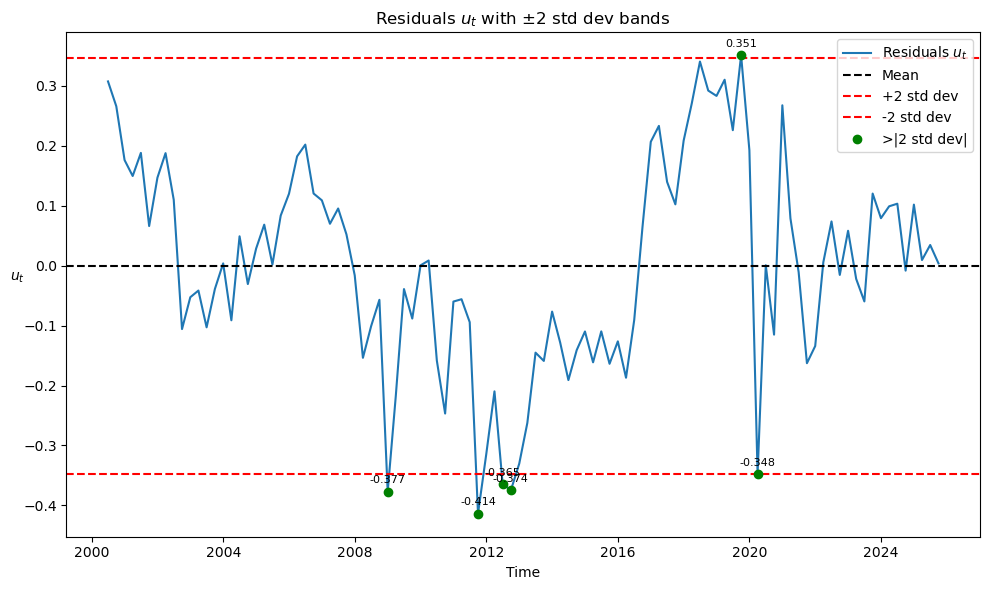

In [41]:
resid = resid_treasury_ukGilt
idx = treasury_ukGilt_df_quarterly.index

# Mean and std.dev 
mu = resid.mean()
sigma = resid.std()

plt.figure(figsize=(10, 6))

# Reaiduals
plt.plot(idx, resid, label="Residuals $u_t$")

# Bands +/- 2 sigma 
plt.axhline(mu,           color="black", linestyle="--", label="Mean")
plt.axhline(mu + 2*sigma, color="red",   linestyle="--", label="+2 std dev")
plt.axhline(mu - 2*sigma, color="red",   linestyle="--", label="-2 std dev")

# Outliers
outliers = resid[(resid > mu + 2*sigma) | (resid < mu - 2*sigma)]

# Scatter plot of outliers
plt.scatter(outliers.index, outliers.values, color="green", zorder=3, label=">|2 std dev|")

for x, y in outliers.items():
# Notes in the chart
    plt.annotate(
        f"{y:.3f}",
        xy=(x, y),
        xytext=(0, 6),                
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title("Residuals $u_t$ with ±2 std dev bands")
plt.xlabel("Time")
plt.ylabel("$u_t$", rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## Question 4

In [42]:
print("\n" + "="*70)
print("REGRESSION ON LEVELS (Y_t on X_t)".center(70))
print("="*70 + "\n")
# Regression on the pair 'log SPX' | 'log GBP/USD'
Y = df_log_quarterly['log SPX']
X = df_log_quarterly['log GBPUSD']
X = sm.add_constant(X)
model = sm.OLS(Y, X, missing='drop')
results = model.fit()

# Results
residuals = results.resid
coefficients = results.params
tvalues = results.tvalues
pvalues = results.pvalues
rsquared = results.rsquared
dw_test = sm.stats.durbin_watson(resids=residuals)

# Visual of the Regression's Results
print(f"{'Variable':<15}{'Coefficient':>12}{'t-Test':>12}{'P-Value':>12}")
print('='*60)
for name in coefficients.index:
    print(f"{name:<15}{coefficients[name]:>12.4f}{tvalues[name]:>12.4f}{pvalues[name]:>12.4f}")
    print('-'*60)
print('\nR-squared:', round(rsquared, 4))
print('Durbin-Watson:', round(dw_test, 4))

print('\n'*2)
# Unit Root Test for the Residuals: Augmented Dickey Fuller
adf_spurious_regression = augm_Dickey_Fuller(residuals, 4, 'n')

print('\n'*2)
# Unit Root Test for the Residuals: Augmented Dickey Fuller without lags
adf_spurious_regression = augm_Dickey_Fuller(residuals, 0, 'n')


                  REGRESSION ON LEVELS (Y_t on X_t)                   

Variable        Coefficient      t-Test     P-Value
const                8.6451     71.6639      0.0000
------------------------------------------------------------
log GBPUSD          -2.6925     -9.6525      0.0000
------------------------------------------------------------

R-squared: 0.4823
Durbin-Watson: 0.1956




                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.11004    -2.00791      0.0476
------------------------------------------------
x2               0.16189     1.51211      0.1339
------------------------------------------------
x3               0.02037     0.19179      0.8483
------------------------------------------------
x4              -0.02737    -0.25875      0.7964
------------------------------------------------
x5               0.02480     0.23148      0.8175
Cri

In [43]:
print("\n" + "="*70)
print("REGRESSION ON FIRST DIFFERENCES (ΔY_t on ΔX_t)".center(70))
print("="*70 + "\n")
# Regression on the pair 'Dlog SPX' | 'Dlog GBP/USD'
Y = df_log_quarterly_diff['log SPX']
X = df_log_quarterly_diff['log GBPUSD']
X = sm.add_constant(X)
model = sm.OLS(Y, X, missing='drop')
results = model.fit()

# Results
residuals = results.resid
coefficients = results.params
tvalues = results.tvalues
pvalues = results.pvalues
rsquared = results.rsquared
dw_test = sm.stats.durbin_watson(resids=residuals)

# Visual of the Regression's Results
print(f"{'Variable':<15}{'Coefficient':>12}{'t-Test':>12}{'P-Value':>12}")
print('='*60)
for name in coefficients.index:
    print(f"{name:<15}{coefficients[name]:>12.4f}{tvalues[name]:>12.4f}{pvalues[name]:>12.4f}")
    print('-'*60)
print('\nR-squared:', round(rsquared, 4))
print('Durbin-Watson:', round(dw_test, 4))

print('\n'*2)
# Unit Root Test for the Residuals: Augmented Dickey Fuller
adf_firstDiff_regression = augm_Dickey_Fuller(residuals, 4, 'n')

print('\n'*2)
# Unit Root Test for the Residuals: Augmented Dickey Fuller without lags
adf_firstDiff_regression = augm_Dickey_Fuller(residuals, 0, 'n')


            REGRESSION ON FIRST DIFFERENCES (ΔY_t on ΔX_t)            

Variable        Coefficient      t-Test     P-Value
const                0.0157      2.0766      0.0404
------------------------------------------------------------
log GBPUSD           0.8201      5.0267      0.0000
------------------------------------------------------------

R-squared: 0.2033
Durbin-Watson: 2.0381




                     ADF Test — Series                      

Variable     Coefficient     t-Value     P-Value
------------------------------------------------
x1              -0.94452    -4.16913      0.0001
------------------------------------------------
x2              -0.08230    -0.40670      0.6852
------------------------------------------------
x3              -0.17167    -0.98910      0.3252
------------------------------------------------
x4              -0.17034    -1.22676      0.2231
------------------------------------------------
x5              -0.16278    -1.66345      0.0997
Cri

## Question 5

In [44]:
# Weekly aggregation: Level Data
df_log_weekly = df_log.resample('W-FRI').last()

# Weekly Differences
df_log_weekly_diff = df_log_weekly.diff().dropna(axis=0)


In [45]:
from statsmodels.tsa.stattools import grangercausalitytests
def granger_test(df, lags):
    grangercausalitytests(df, [lags], verbose=True)

In [46]:

lags_to_test = [5, 10]

# Columns to use (exclude "log US Yields")
all_cols = [
    "log SPX",
    "log Gas",
    "log GBPUSD",
    "log 10yr Tr. Yield",
    "log spread 10yr_Tr-Corp",
]

# 1) Y = SPX
print("\n\n########## Y = log SPX ##########")
for x in all_cols:
    if x == "log SPX":
        continue
    print(f"\n=== Regressor: {x}")
    for L in lags_to_test:
        print(f"\n--- Granger test (lag = {L}) ---")
        granger_test(df_log_weekly_diff[["log SPX", x]], L)

# 2) Y = Gas
print("\n\n########## Y = log Gas ##########")
for x in all_cols:
    if x == "log Gas":
        continue
    print(f"\n=== Regressor: {x}")
    for L in lags_to_test:
        print(f"\n--- Granger test (lag = {L}) ---")
        granger_test(df_log_weekly_diff[["log Gas", x]], L)

# 3) Y = GBPUSD
print("\n\n########## Y = log GBPUSD ##########")
for x in all_cols:
    if x == "log GBPUSD":
        continue
    print(f"\n=== Regressor: {x}")
    for L in lags_to_test:
        print(f"\n--- Granger test (lag = {L}) ---")
        granger_test(df_log_weekly_diff[["log GBPUSD", x]], L)

# 4) Y = 10yr Treasury Yield
print("\n\n########## Y = log 10yr Tr. Yield ##########")
for x in all_cols:
    if x == "log 10yr Tr. Yield":
        continue
    print(f"\n=== Regressor: {x}")
    for L in lags_to_test:
        print(f"\n--- Granger test (lag = {L}) ---")
        granger_test(df_log_weekly_diff[["log 10yr Tr. Yield", x]], L)

# 5) Y = corporate spread
print("\n\n########## Y = log spread 10yr_Tr-Corp ##########")
for x in all_cols:
    if x == "log spread 10yr_Tr-Corp":
        continue
    print(f"\n=== Regressor: {x}")
    for L in lags_to_test:
        print(f"\n--- Granger test (lag = {L}) ---")
        granger_test(df_log_weekly_diff[["log spread 10yr_Tr-Corp", x]], L)



########## Y = log SPX ##########

=== Regressor: log Gas

--- Granger test (lag = 5) ---

Granger Causality
number of lags (no zero) 5
ssr based F test:         F=1.4313  , p=0.2101  , df_denom=1320, df_num=5
ssr based chi2 test:   chi2=7.2162  , p=0.2051  , df=5
likelihood ratio test: chi2=7.1967  , p=0.2064  , df=5
parameter F test:         F=1.4313  , p=0.2101  , df_denom=1320, df_num=5

--- Granger test (lag = 10) ---

Granger Causality
number of lags (no zero) 10
ssr based F test:         F=1.3993  , p=0.1748  , df_denom=1305, df_num=10
ssr based chi2 test:   chi2=14.2184 , p=0.1633  , df=10
likelihood ratio test: chi2=14.1427 , p=0.1666  , df=10
parameter F test:         F=1.3993  , p=0.1748  , df_denom=1305, df_num=10

=== Regressor: log GBPUSD

--- Granger test (lag = 5) ---

Granger Causality
number of lags (no zero) 5
ssr based F test:         F=1.6138  , p=0.1533  , df_denom=1320, df_num=5
ssr based chi2 test:   chi2=8.1362  , p=0.1489  , df=5
likelihood ratio test: chi2=

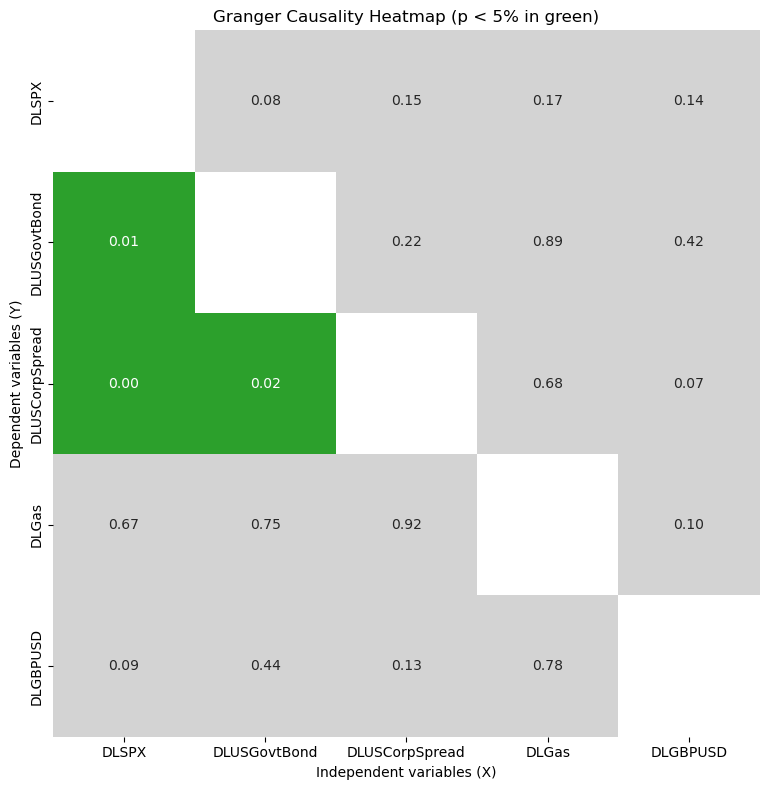

In [47]:
import seaborn as sns
import matplotlib.colors as mcolors

# Load Granger causality tracker
# Rows   = dependent variables (Y)
# Columns = independent variables (X)
granger_tracker = pd.read_excel(
    '/Users/enrico/Downloads/Granger_Causality_tracker-3.xlsx',
    sheet_name='Summary',
    header=0,
    index_col=0
)

# If values are p-values in [0, 1]:
bounds = [0.0, 0.05, 1.0]   # [0, 5%, 100%]

colors = ['#2ca02c', '#d3d3d3']  # green, grey
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 8))
sns.heatmap(
    granger_tracker,
    annot=True,      # show values in each cell
    fmt=".2f",       
    cmap=cmap,
    norm=norm,
    cbar=False,      # set to True if you want a colorbar legend
    square=True
)

plt.title("Granger Causality Heatmap (p < 5% in green)")
plt.xlabel("Independent variables (X)")
plt.ylabel("Dependent variables (Y)")

plt.tight_layout()
plt.show()

## Question 6

In [48]:
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import skew, kurtosis, norm

from arch import arch_model


def arma_garch_report(
    y,
    name: str,
    ar: int,
    ma: int,
    vol: str,
    p: int = 1,
    o: int = 0,
    q: int = 1,
    dist: str = "normal",
    q_lags=(5, 10, 20),
    arch_lags=(5,),
):
    """
    y    : 1D series of returns (pandas Series or array-like).
    name : label for the series (printed in the header).

    Mean equation   : ARMA(ar, ma) via statsmodels.ARIMA(ar,0,ma)
    Volatility      : GARCH-type with arch_model(mean="Zero", vol=vol, p,o,q)
    dist            : "normal" or "StudentsT"
    q_lags          : lags for Ljung–Box on standardized residuals and squares
    arch_lags       : lags for ARCH LM tests on standardized residuals
    """

    ################################################################################
    # 0. Prepare data
    ################################################################################
    y = pd.Series(y).dropna()
    nobs = len(y)
    idx = y.index
    start = idx[0] if len(idx) > 0 else ""
    end   = idx[-1] if len(idx) > 0 else ""

    ################################################################################
    # 1. ARMA mean equation
    ################################################################################
    arma_model = ARIMA(y, order=(ar, 0, ma))
    arma_res   = arma_model.fit()

    eps = arma_res.resid  # these are the innovations to be modelled by GARCH

    ################################################################################
    # 2. GARCH volatility on ARMA residuals
    ################################################################################
    am = arch_model(
        eps,
        mean="Zero",          # mean already captured by ARMA
        vol=vol,
        p=p,
        o=o,
        q=q,
        dist=dist
    )
    garch_res = am.fit(disp="off")

    ################################################################################
    # 3. Basic statistics
    ################################################################################
    y_mean = y.mean()
    y_var  = y.var(ddof=1)
    y_skew = skew(y, bias=False)
    y_ex_kurt = kurtosis(y, fisher=True, bias=False)   # excess kurtosis

    v_params = garch_res.params
    v_stderr = garch_res.std_err
    v_tvals  = garch_res.tvalues
    v_pvals  = garch_res.pvalues

    m_params = arma_res.params
    m_stderr = arma_res.bse
    m_tvals  = arma_res.tvalues
    m_pvals  = arma_res.pvalues

    std_resid = garch_res.std_resid

    # log-likelihood and information criteria (GARCH block)
    loglik  = garch_res.loglikelihood
    T_eff   = garch_res.nobs
    k_garch = v_params.size
    aic = -2 * loglik + 2 * k_garch
    sic = -2 * loglik + k_garch * np.log(T_eff)

    ################################################################################
    # 4. Normality and residual diagnostics
    ################################################################################
    jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(std_resid)

    # Approximate t-tests on skewness and kurtosis of the original series
    se_skew = np.sqrt(6.0 / nobs)
    se_kurt = np.sqrt(24.0 / nobs)
    t_skew  = y_skew / se_skew
    p_skew  = 2 * (1 - norm.cdf(abs(t_skew)))
    t_kurt  = y_ex_kurt / se_kurt
    p_kurt  = 2 * (1 - norm.cdf(abs(t_kurt)))

    # Ljung–Box on standardized residuals and their squares
    lb_std = acorr_ljungbox(std_resid, lags=list(q_lags), return_df=True)
    lb_sq  = acorr_ljungbox(std_resid**2, lags=list(q_lags), return_df=True)

    # ARCH LM tests
    arch_tests = []
    for L in arch_lags:
        lm_stat, lm_pval, f_stat, f_pval = het_arch(std_resid, nlags=L)
        arch_tests.append((L, f_stat, f_pval))

    ################################################################################
    # 5. Results
    ################################################################################
    print("\n" + "*" * 70)
    print(f"** {name}: ARMA({ar},{ma}) - {vol}({p},{o},{q}) with {dist} innovations **")
    print("*" * 70)
    if start != "":
        print(f"Sample: {start}  to  {end}  |  Observations: {nobs}")
    print()

    # Mean equation
    print("Mean Equation (ARMA)")
    print("{:<15}{:>12}{:>12}{:>10}{:>10}"
          .format("Parameter", "Coef", "Std.Err", "t-stat", "p-value"))
    for pname, coef in m_params.items():
        se = m_stderr[pname]
        t  = m_tvals[pname]
        pv = m_pvals[pname]
        print("{:<15}{:>12.6f}{:>12.6f}{:>10.3f}{:>10.4f}"
              .format(pname, coef, se, t, pv))
    print()

    # Variance equation
    print("Variance Equation ({})".format(vol))
    print("{:<15}{:>12}{:>12}{:>10}{:>10}"
          .format("Parameter", "Coef", "Std.Err", "t-stat", "p-value"))
    for pname, coef in v_params.items():
        se = v_stderr[pname]
        t  = v_tvals[pname]
        pv = v_pvals[pname]
        print("{:<15}{:>12.6f}{:>12.6f}{:>10.3f}{:>10.4f}"
              .format(pname, coef, se, t, pv))
    print()

    print(f"Mean(Y)      : {y_mean:>10.6f}   Var(Y)   : {y_var:>10.6f}")
    print(f"Skewness(Y)  : {y_skew:>10.6f}   Kurtosis : {y_ex_kurt + 3:>10.6f}")
    print(f"logLik (GARCH): {loglik:>10.4f}   AIC: {aic:>10.4f}   SIC: {sic:>10.4f}")
    print()

    print("Normality (Jarque–Bera on standardized residuals)")
    print("{:<18}{:>10}{:>10}{:>10}"
          .format("", "Statistic", "t-test", "p-value"))
    print("{:<18}{:>10.4f}{:>10.4f}{:>10.4g}"
          .format("Skewness(Y)", y_skew, t_skew, p_skew))
    print("{:<18}{:>10.4f}{:>10.4f}{:>10.4g}"
          .format("Excess Kurt.", y_ex_kurt, t_kurt, p_kurt))
    print("{:<18}{:>10.4f}{:>10}{:>10.4g}"
          .format("Jarque-Bera", jb_stat, "", jb_pval))
    print()

    print("Ljung–Box Q on standardized residuals")
    for lag in q_lags:
        q_stat = lb_std.loc[lag, "lb_stat"]
        q_pval = lb_std.loc[lag, "lb_pvalue"]
        print(f"Q({lag:>2}) = {q_stat:8.3f}  [p = {q_pval:8.6f}]")
    print("H0: no serial correlation\n")

    print("Ljung–Box Q on squared standardized residuals")
    for lag in q_lags:
        q_stat = lb_sq.loc[lag, "lb_stat"]
        q_pval = lb_sq.loc[lag, "lb_pvalue"]
        print(f"Q({lag:>2}) = {q_stat:8.3f}  [p = {q_pval:8.6f}]")
    print("H0: no remaining ARCH effect\n")

    print("ARCH LM tests on squared standardized residuals")
    for L, f_stat, f_pval in arch_tests:
        df1 = L
        df2 = nobs - L - 1
        print(f"ARCH 1-{L} test:  F({df1},{df2}) = {f_stat:8.3f}  [p = {f_pval:8.6f}]")
    print()

In [49]:

# 1. SPX: ARMA(1,1) – GJR-GARCH(1,1), Student-t
arma_garch_report(
    df_log_weekly_diff["log SPX"],
    name="SPX",
    ar=1,
    ma=1,
    vol="GARCH",
    p=1,
    o=1,        # THIS IMPLIES GJR
    q=1,
    dist="StudentsT"
)

# 2. Govt Bond: ARMA(0,0) – EGARCH(1,1), Normal
arma_garch_report(
    df_log_weekly_diff["log 10yr Tr. Yield"],
    name="10yr Treasury Yield",
    ar=0,
    ma=0,
    vol="EGARCH",
    p=1,
    o=0,
    q=1,
    dist="normal"
)

# 3. Corporate spread: ARMA(2,2) – GARCH(1,1), Student-t
arma_garch_report(
    df_log_weekly_diff["log spread 10yr_Tr-Corp"],
    name="10yr Treasury – Corp Spread",
    ar=2,
    ma=2,
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="StudentsT"
)

# 4. GBPUSD: ARMA(1,1) – GARCH(1,1), Normal
arma_garch_report(
    df_log_weekly_diff["log GBPUSD"],
    name="GBPUSD",
    ar=1,
    ma=1,
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="normal"
)

# 5. Gas: ARMA(2,2) – GARCH(1,1), Student-t
arma_garch_report(
    df_log_weekly_diff["log Gas"],
    name="Natural Gas",
    ar=2,
    ma=2,
    vol="GARCH",
    p=1,
    o=0,
    q=1,
    dist="StudentsT"
)

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.


**********************************************************************
** SPX: ARMA(1,1) - GARCH(1,1,1) with StudentsT innovations **
**********************************************************************
Sample: 2000-01-14 00:00:00  to  2025-08-29 00:00:00  |  Observations: 1336

Mean Equation (ARMA)
Parameter              Coef     Std.Err    t-stat   p-value
const              0.001131    0.000724     1.563    0.1181
ar.L1             -0.798499    0.087935    -9.081    0.0000
ma.L1              0.742942    0.095317     7.794    0.0000
sigma2             0.000613    0.000012    52.641    0.0000

Variance Equation (GARCH)
Parameter              Coef     Std.Err    t-stat   p-value
omega              0.000061    0.000059     1.032    0.3021
alpha[1]           0.100000    0.227304     0.440    0.6600
gamma[1]           0.200000    0.133362     1.500    0.1337
beta[1]            0.700000    0.192367     3.639    0.0003
nu                 6.781644    3.645801     1.860    0.0629

Mean(Y) 

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.


**********************************************************************
** Natural Gas: ARMA(2,2) - GARCH(1,0,1) with StudentsT innovations **
**********************************************************************
Sample: 2000-01-14 00:00:00  to  2025-08-29 00:00:00  |  Observations: 1336

Mean Equation (ARMA)
Parameter              Coef     Std.Err    t-stat   p-value
const              0.000116    0.002268     0.051    0.9591
ar.L1             -0.252381    0.123266    -2.047    0.0406
ar.L2              0.545104    0.055488     9.824    0.0000
ma.L1              0.060747    0.122432     0.496    0.6198
ma.L2             -0.651948    0.068785    -9.478    0.0000
sigma2             0.014589    0.000155    94.190    0.0000

Variance Equation (GARCH)
Parameter              Coef     Std.Err    t-stat   p-value
omega              0.001111    0.000327     3.402    0.0007
alpha[1]           0.316757    0.057701     5.490    0.0000
beta[1]            0.627405    0.052681    11.910    0.0000
n

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
